# European Football Analysis
Analysis of 25,000+ matches across 11 European leagues (2008–2016).

**Dataset:** European Soccer Database (Kaggle)  
**Tools:** Python, SQLite, pandas, matplotlib, seaborn

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = r"C:\Users\Josip\Desktop\SQL_project\database.sqlite"

conn = sqlite3.connect(path)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes


## 2. Database Exploration

In [3]:
for table in tables['name']:
    print(f"\n=== {table} ===")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 3", conn)
    print(f"Columns: {df.columns.tolist()}")
    print(f"Rows in table: {pd.read_sql(f'SELECT COUNT(*) as cnt FROM {table}', conn)['cnt'][0]:,}")


=== sqlite_sequence ===
Columns: ['name', 'seq']
Rows in table: 7

=== Player_Attributes ===
Columns: ['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating', 'potential', 'preferred_foot', 'attacking_work_rate', 'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']
Rows in table: 183,978

=== Player ===
Columns: ['id', 'player_api_id', 'player_name', 'player_fifa_api_id', 'birthday', 'height', 'weight']
Rows in table: 11,060

=== Match ===
Columns: ['id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id', 'home_team_api

### League Overview
11 European leagues with 25,000+ matches total.

In [4]:
query = """
SELECT 
    c.name AS country,
    l.name AS league,
    COUNT(m.id) AS total_matches
FROM Match m
JOIN League l ON m.league_id = l.id
JOIN Country c ON l.country_id = c.id
GROUP BY l.name, c.name
ORDER BY total_matches DESC
"""

df_leagues = pd.read_sql(query, conn)
print(df_leagues)

        country                    league  total_matches
0       England    England Premier League           3040
1        France            France Ligue 1           3040
2         Spain           Spain LIGA BBVA           3040
3         Italy             Italy Serie A           3017
4       Germany     Germany 1. Bundesliga           2448
5   Netherlands    Netherlands Eredivisie           2448
6      Portugal  Portugal Liga ZON Sagres           2052
7        Poland        Poland Ekstraklasa           1920
8      Scotland   Scotland Premier League           1824
9       Belgium    Belgium Jupiler League           1728
10  Switzerland  Switzerland Super League           1422


## 3. Win Rate Analysis — England Premier League

Which teams won the most across all seasons (2008–2016)?  
Minimum 100 matches played to filter out promoted/relegated clubs.

In [5]:
query = """
SELECT 
    t.team_long_name AS team,
    COUNT(*) AS total_matches,
    SUM(CASE 
        WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 1
        WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 1
        ELSE 0 
    END) AS wins,
    ROUND(100.0 * SUM(CASE 
        WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 1
        WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 1
        ELSE 0 
    END) / COUNT(*), 1) AS win_rate
FROM Match m
JOIN Team t ON t.team_api_id = m.home_team_api_id 
           OR t.team_api_id = m.away_team_api_id
JOIN League l ON m.league_id = l.id
WHERE l.name = 'England Premier League'
GROUP BY t.team_long_name
HAVING total_matches >= 100
ORDER BY win_rate DESC
LIMIT 10
"""

df_winrate = pd.read_sql(query, conn)
print(df_winrate)

                team  total_matches  wins  win_rate
0  Manchester United            304   192      63.2
1            Chelsea            304   176      57.9
2    Manchester City            304   175      57.6
3            Arsenal            304   170      55.9
4  Tottenham Hotspur            304   151      49.7
5          Liverpool            304   150      49.3
6            Everton            304   121      39.8
7        Southampton            152    60      39.5
8       Swansea City            190    62      32.6
9     Crystal Palace            114    37      32.5


### Findings
- **Manchester United** dominates with 63.2% win rate across 304 matches
- Clear gap between top 4 (Man Utd, Chelsea, Man City, Arsenal) and the rest
- Liverpool surprisingly close to Tottenham despite stronger reputation in this period

### Win Rate Visualization

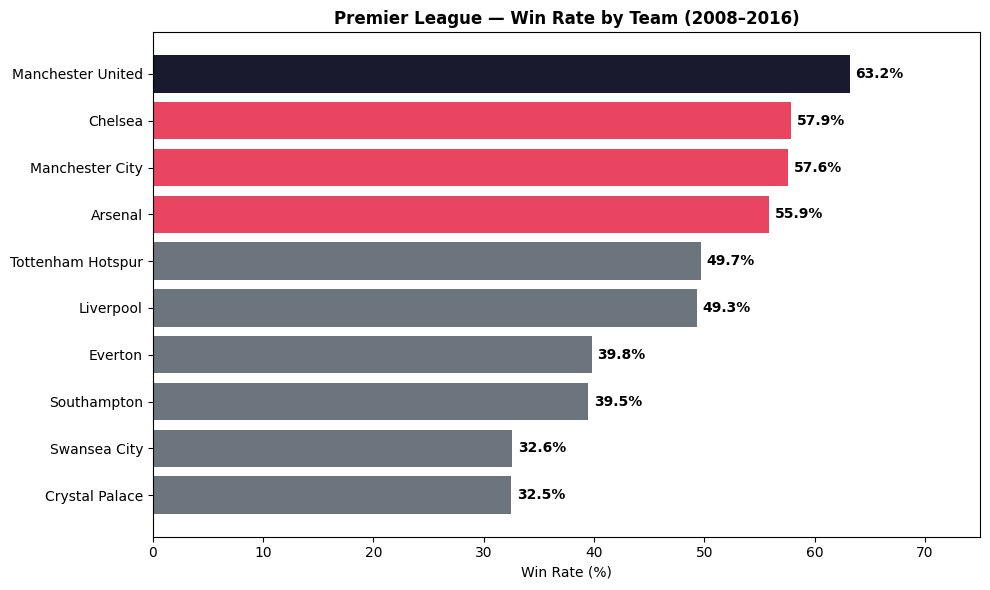

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1a1a2e' if i == 0 else '#e94560' if i < 4 else '#6c757d' 
          for i in range(len(df_winrate))]

bars = ax.barh(df_winrate['team'], df_winrate['win_rate'], color=colors)

ax.set_xlabel('Win Rate (%)')
ax.set_title('Premier League — Win Rate by Team (2008–2016)', fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, df_winrate['win_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

ax.set_xlim(0, 75)
plt.tight_layout()
plt.show()

## 4. Home vs Away Advantage

Does playing at home significantly impact win rate across all leagues?

In [7]:
query = """
SELECT 
    l.name AS league,
    ROUND(100.0 * SUM(CASE WHEN home_team_goal > away_team_goal THEN 1 ELSE 0 END) / COUNT(*), 1) AS home_win_pct,
    ROUND(100.0 * SUM(CASE WHEN home_team_goal < away_team_goal THEN 1 ELSE 0 END) / COUNT(*), 1) AS away_win_pct,
    ROUND(100.0 * SUM(CASE WHEN home_team_goal = away_team_goal THEN 1 ELSE 0 END) / COUNT(*), 1) AS draw_pct
FROM Match m
JOIN League l ON m.league_id = l.id
GROUP BY l.name
ORDER BY home_win_pct DESC
"""

df_home = pd.read_sql(query, conn)
print(df_home)

                      league  home_win_pct  away_win_pct  draw_pct
0            Spain LIGA BBVA          48.8          28.0      23.2
1     Netherlands Eredivisie          47.8          28.4      23.7
2     Belgium Jupiler League          46.9          28.5      24.6
3              Italy Serie A          46.6          27.0      26.4
4   Switzerland Super League          45.7          30.0      24.3
5     England Premier League          45.7          28.5      25.8
6         Poland Ekstraklasa          45.3          27.3      27.3
7      Germany 1. Bundesliga          45.2          30.4      24.4
8             France Ligue 1          44.7          27.0      28.3
9   Portugal Liga ZON Sagres          44.2          29.8      26.0
10   Scotland Premier League          41.7          33.8      24.5


### Home vs Away Advantage by League

Home advantage is consistent across all leagues — but how big is the gap?

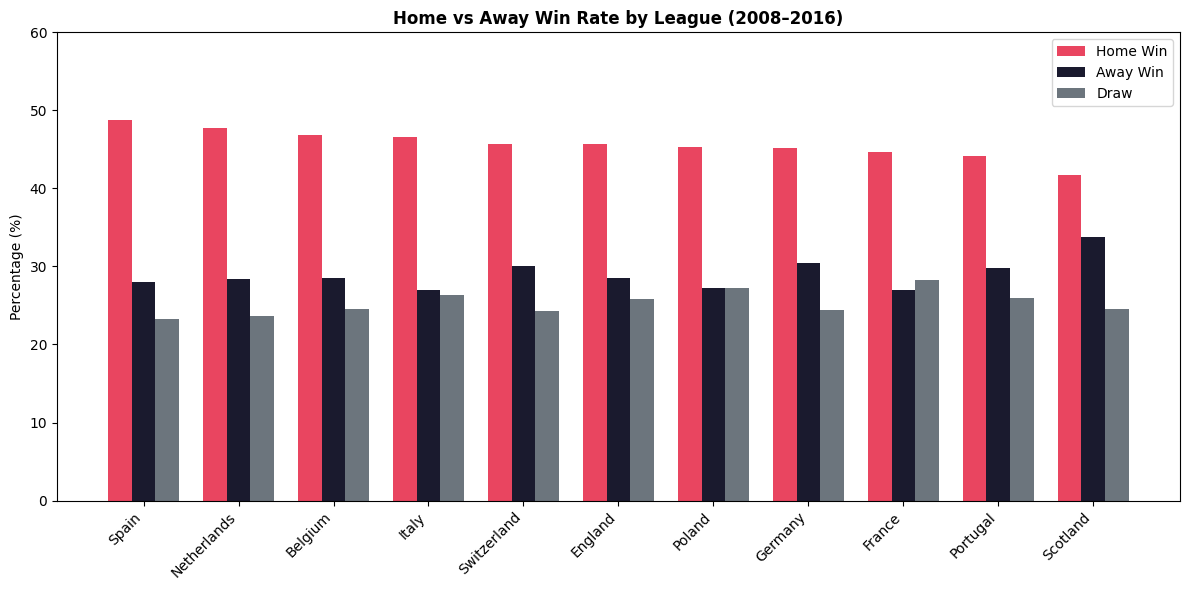

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_home))
width = 0.25

bars1 = ax.bar([i - width for i in x], df_home['home_win_pct'], width, label='Home Win', color='#e94560')
bars2 = ax.bar(x, df_home['away_win_pct'], width, label='Away Win', color='#1a1a2e')
bars3 = ax.bar([i + width for i in x], df_home['draw_pct'], width, label='Draw', color='#6c757d')

ax.set_xticks(x)
ax.set_xticklabels([l.split(' ')[0] for l in df_home['league']], rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Home vs Away Win Rate by League (2008–2016)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()

### Findings
- Home advantage exists in **every single league** — no exceptions
- **Spain** has the strongest home advantage (48.8% home vs 28.0% away)
- **Scotland** has the weakest home advantage — most "balanced" league
- Draw rates highest in France and Poland (~27-28%)

## 5. Goal Scoring Trends Over Time

Are matches becoming more or less entertaining (goal-rich) across seasons?

In [9]:
query = """
SELECT 
    season,
    ROUND(AVG(home_team_goal + away_team_goal), 2) AS avg_goals_per_match,
    ROUND(AVG(home_team_goal), 2) AS avg_home_goals,
    ROUND(AVG(away_team_goal), 2) AS avg_away_goals,
    COUNT(*) AS total_matches
FROM Match
GROUP BY season
ORDER BY season
"""

df_goals = pd.read_sql(query, conn)
print(df_goals)

      season  avg_goals_per_match  avg_home_goals  avg_away_goals   
0  2008/2009                 2.61            1.51            1.10  \
1  2009/2010                 2.67            1.54            1.13   
2  2010/2011                 2.68            1.55            1.14   
3  2011/2012                 2.72            1.57            1.14   
4  2012/2013                 2.77            1.55            1.22   
5  2013/2014                 2.77            1.58            1.19   
6  2014/2015                 2.68            1.52            1.16   
7  2015/2016                 2.75            1.54            1.21   

   total_matches  
0           3326  
1           3230  
2           3260  
3           3220  
4           3260  
5           3032  
6           3325  
7           3326  


### Goal Scoring Trends Visualization

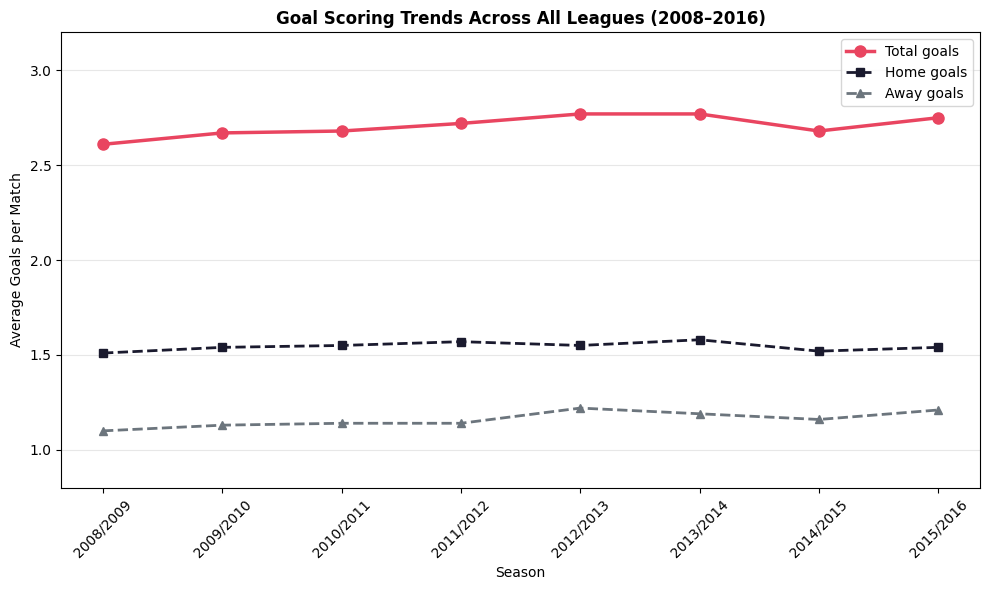

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_goals['season'], df_goals['avg_goals_per_match'], 
        marker='o', linewidth=2.5, color='#e94560', label='Total goals', markersize=8)
ax.plot(df_goals['season'], df_goals['avg_home_goals'], 
        marker='s', linewidth=2, color='#1a1a2e', label='Home goals', markersize=6, linestyle='--')
ax.plot(df_goals['season'], df_goals['avg_away_goals'], 
        marker='^', linewidth=2, color='#6c757d', label='Away goals', markersize=6, linestyle='--')

ax.set_xlabel('Season')
ax.set_ylabel('Average Goals per Match')
ax.set_title('Goal Scoring Trends Across All Leagues (2008–2016)', fontweight='bold')
ax.legend()
ax.set_ylim(0.8, 3.2)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Findings
- Average goals per match **increased slightly** from 2.61 (2008) to 2.75 (2015/16)
- **Away goals growing** faster than home goals — away teams becoming bolder
- Peak season: **2012/13 and 2013/14** with 2.77 goals per match
- Home goal advantage **consistent** throughout all seasons (~1.53 avg)

## 6. Team Form — Winning Streaks

Which teams had the longest consecutive winning runs?  
This query uses **window functions** to track match-by-match form.

In [11]:
query = """
WITH match_results AS (
    SELECT 
        t.team_long_name AS team,
        m.date,
        m.season,
        CASE 
            WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 'W'
            WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 'W'
            ELSE 'NW'
        END AS result
    FROM Match m
    JOIN Team t ON t.team_api_id = m.home_team_api_id 
               OR t.team_api_id = m.away_team_api_id
    JOIN League l ON m.league_id = l.id
    WHERE l.name = 'England Premier League'
),
streak_groups AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY team ORDER BY date) -
        ROW_NUMBER() OVER (PARTITION BY team, result ORDER BY date) AS grp
    FROM match_results
)
SELECT 
    team,
    result,
    COUNT(*) AS streak_length
FROM streak_groups
WHERE result = 'W'
GROUP BY team, grp, result
ORDER BY streak_length DESC
LIMIT 10
"""

df_streaks = pd.read_sql(query, conn)
print(df_streaks)

                team result  streak_length
0            Chelsea      W             11
1          Liverpool      W             11
2    Manchester City      W             11
3  Manchester United      W             11
4            Arsenal      W              8
5            Chelsea      W              8
6    Manchester City      W              8
7  Manchester United      W              8
8            Arsenal      W              7
9            Everton      W              7


### Longest Winning Streaks Visualization

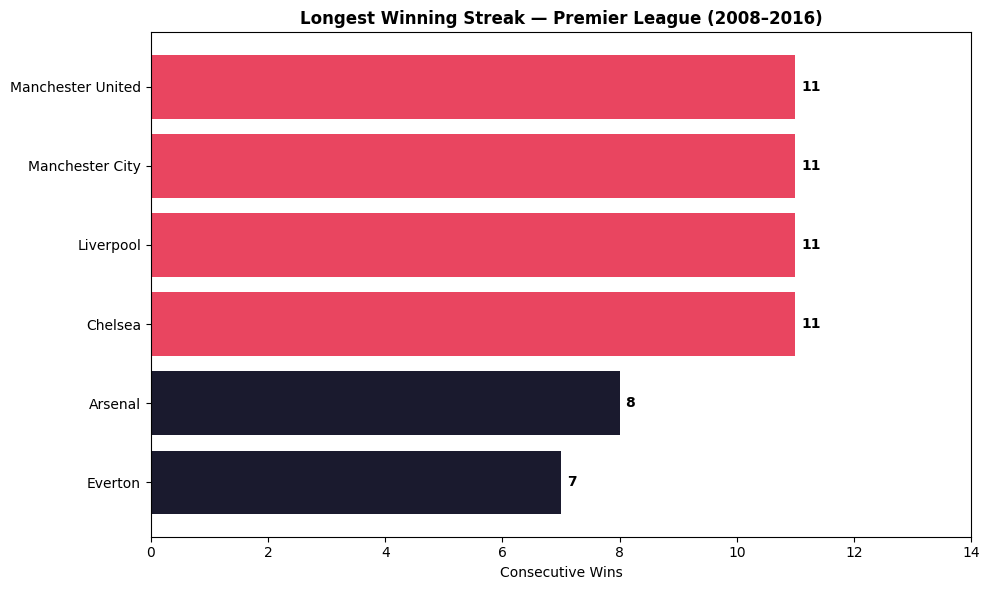

In [15]:
# Top streak per team
df_best_streaks = df_streaks.groupby('team')['streak_length'].max().reset_index()
df_best_streaks = df_best_streaks.sort_values('streak_length', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e94560' if v == df_best_streaks['streak_length'].max() 
          else '#1a1a2e' for v in df_best_streaks['streak_length']]

bars = ax.barh(df_best_streaks['team'], df_best_streaks['streak_length'], color=colors)

for bar, val in zip(bars, df_best_streaks['streak_length']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_xlabel('Consecutive Wins')
ax.set_title('Longest Winning Streak — Premier League (2008–2016)', fontweight='bold')
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()

### Findings
- **Chelsea, Liverpool, Man City and Man Utd** all share the record — 11 consecutive wins
- Big 4 dominance clear — all streaks of 8+ belong to top clubs
- **Everton** impressive with 7 consecutive wins as a mid-table club

## 7. Most Consistent Teams

Which teams maintained stable performance across all seasons?  
Consistency = low standard deviation in win rate year over year.

In [13]:
query = """
SELECT 
    t.team_long_name AS team,
    m.season,
    COUNT(*) AS matches,
    ROUND(100.0 * SUM(CASE 
        WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 1
        WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 1
        ELSE 0 END) / COUNT(*), 1) AS win_rate
FROM Match m
JOIN Team t ON t.team_api_id = m.home_team_api_id 
           OR t.team_api_id = m.away_team_api_id
JOIN League l ON m.league_id = l.id
WHERE l.name = 'England Premier League'
GROUP BY t.team_long_name, m.season
HAVING matches >= 30
"""

df_consistency = pd.read_sql(query, conn)

# Consistency = low std dev across seasons
consistency = df_consistency.groupby('team')['win_rate'].agg(
    seasons='count',
    avg_win_rate='mean',
    std_win_rate='std'
).round(1).reset_index()

consistency = consistency[consistency['seasons'] >= 5].sort_values('std_win_rate')
print(consistency.head(10))

                    team  seasons  avg_win_rate  std_win_rate
32        Wigan Athletic        5          26.3           3.7
26            Sunderland        8          25.6           4.2
0                Arsenal        8          55.9           4.4
25            Stoke City        8          32.2           5.0
12                Fulham        6          31.1           5.1
27          Swansea City        5          32.6           5.5
30  West Bromwich Albion        7          28.2           6.7
28     Tottenham Hotspur        8          49.7           6.8
31       West Ham United        7          30.1           8.3
11               Everton        8          39.8           8.4


### Consistency vs Performance

Low std deviation = consistent. But are consistent teams also good teams?

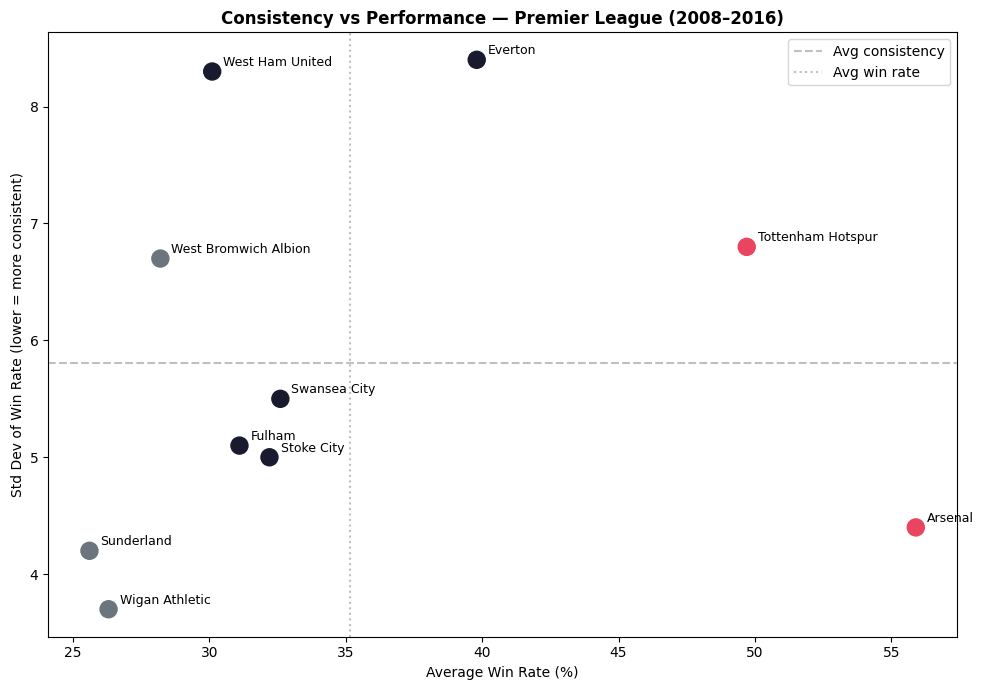

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e94560' if wr >= 45 else '#1a1a2e' if wr >= 30 else '#6c757d' 
          for wr in consistency.head(10)['avg_win_rate']]

scatter = ax.scatter(
    consistency.head(10)['avg_win_rate'],
    consistency.head(10)['std_win_rate'],
    c=colors, s=150, zorder=5
)

for _, row in consistency.head(10).iterrows():
    ax.annotate(row['team'], 
                (row['avg_win_rate'], row['std_win_rate']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.axhline(y=consistency.head(10)['std_win_rate'].mean(), 
           color='gray', linestyle='--', alpha=0.5, label='Avg consistency')
ax.axvline(x=consistency.head(10)['avg_win_rate'].mean(), 
           color='gray', linestyle=':', alpha=0.5, label='Avg win rate')

ax.set_xlabel('Average Win Rate (%)')
ax.set_ylabel('Std Dev of Win Rate (lower = more consistent)')
ax.set_title('Consistency vs Performance — Premier League (2008–2016)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Findings
- **Arsenal** — best of both worlds: high win rate (55.9%) AND most consistent top team (std 4.4)
- **Wigan & Sunderland** — consistent but consistently average (~26%)
- **Everton** — high variance despite mid-table position
- Bottom-left quadrant = consistent underperformers, top-right = inconsistent overperformers

## Summary & Key Insights

### Dataset
- 25,979 matches across 11 European leagues (2008–2016)
- 299 teams, 11,060 players

### Key Findings

**1. Win Rate (Premier League)**
- Manchester United dominated with 63.2% win rate
- Clear gap between Big 4 and rest of the league

**2. Home Advantage**
- Home teams win more in every single league — no exceptions
- Spain has strongest home advantage (48.8%), Scotland weakest (41.7%)

**3. Goal Trends**
- Slight upward trend from 2.61 to 2.75 goals/match over 8 seasons
- Away goals growing faster than home goals

**4. Winning Streaks**
- Chelsea, Liverpool, Man City and Man Utd all hit 11 consecutive wins
- Big 4 dominate all streaks of 8+

**5. Consistency**
- Arsenal: best combination of high performance (55.9%) and consistency (std 4.4)
- Tottenham: high win rate but most inconsistent top club

### Tools Used
- **SQL** — CTEs, window functions, aggregations, JOINs
- **Python** — pandas, matplotlib, seaborn
- **Database** — SQLite (European Soccer Database, Kaggle)

## 8. Cross-League Comparison — England vs Spain vs Germany

How do the top 3 leagues compare in terms of competitiveness and goal scoring?

In [18]:
query = """
SELECT
    l.name AS league,
    t.team_long_name AS team,
    COUNT(*) AS total_matches,
    ROUND(100.0 * SUM(CASE
        WHEN m.home_team_api_id = t.team_api_id AND m.home_team_goal > m.away_team_goal THEN 1
        WHEN m.away_team_api_id = t.team_api_id AND m.away_team_goal > m.home_team_goal THEN 1
        ELSE 0
    END) / COUNT(*), 1) AS win_rate
FROM Match m
JOIN Team t ON t.team_api_id = m.home_team_api_id
           OR t.team_api_id = m.away_team_api_id
JOIN League l ON m.league_id = l.id
WHERE l.name IN ('England Premier League', 'Spain LIGA BBVA', 'Germany 1. Bundesliga')
GROUP BY l.name, t.team_long_name
HAVING total_matches >= 100
ORDER BY l.name, win_rate DESC
"""

df_cross = pd.read_sql(query, conn)

# Top 5 per league
top5 = df_cross.groupby('league').apply(
    lambda x: x.nlargest(5, 'win_rate')
).reset_index(drop=True)

print(top5)

                    league                 team  total_matches  win_rate
0   England Premier League    Manchester United            304      63.2
1   England Premier League              Chelsea            304      57.9
2   England Premier League      Manchester City            304      57.6
3   England Premier League              Arsenal            304      55.9
4   England Premier League    Tottenham Hotspur            304      49.7
5    Germany 1. Bundesliga     FC Bayern Munich            272      71.0
6    Germany 1. Bundesliga    Borussia Dortmund            272      57.7
7    Germany 1. Bundesliga  Bayer 04 Leverkusen            272      50.4
8    Germany 1. Bundesliga        FC Schalke 04            272      46.7
9    Germany 1. Bundesliga        VfL Wolfsburg            272      43.0
10         Spain LIGA BBVA         FC Barcelona            304      77.0
11         Spain LIGA BBVA       Real Madrid CF            304      75.0
12         Spain LIGA BBVA      Atlético Madrid    

### Top 5 Teams by Win Rate — England vs Spain vs Germany

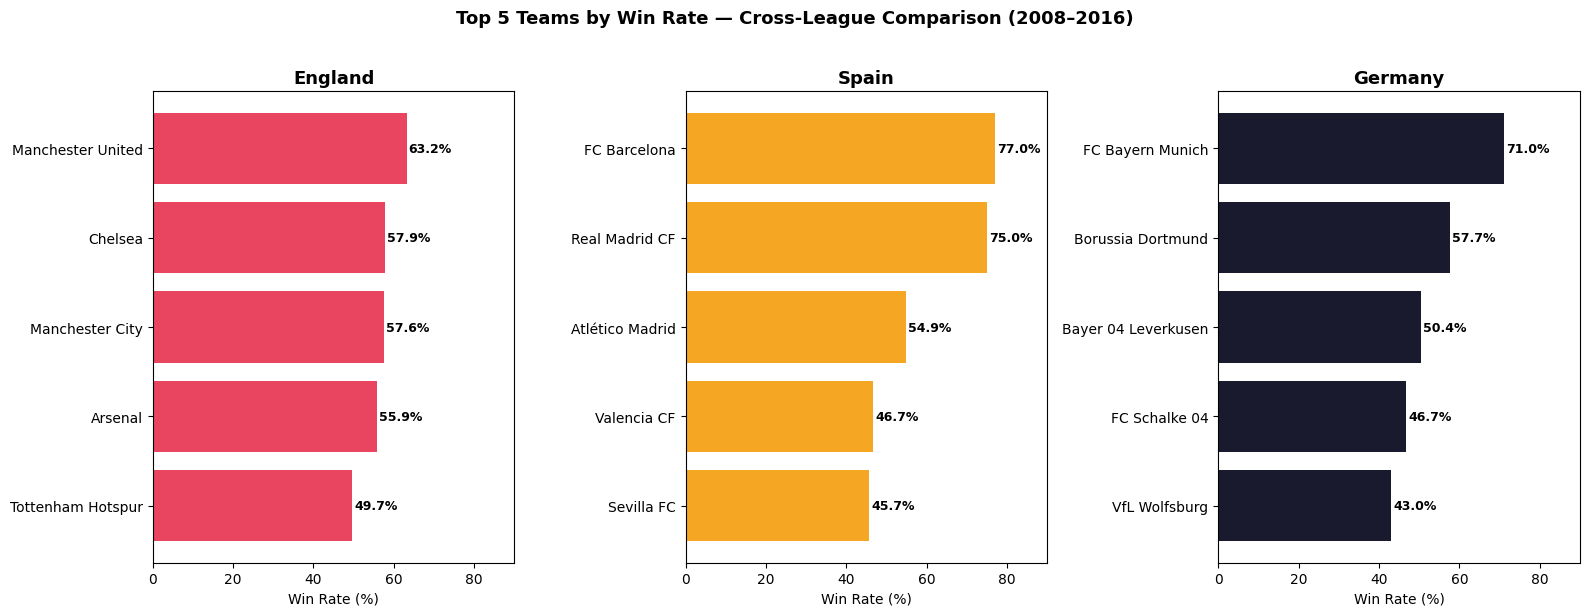

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

leagues = [
    ('England Premier League', '#e94560'),
    ('Spain LIGA BBVA',        '#f5a623'),
    ('Germany 1. Bundesliga',  '#1a1a2e'),
]

for ax, (league, color) in zip(axes, leagues):
    data = top5[top5['league'] == league]
    bars = ax.barh(data['team'], data['win_rate'], color=color)
    ax.invert_yaxis()
    ax.set_xlim(0, 90)
    ax.set_title(league.split(' ')[0], fontweight='bold', fontsize=13)
    ax.set_xlabel('Win Rate (%)')
    for bar, val in zip(bars, data['win_rate']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Top 5 Teams by Win Rate — Cross-League Comparison (2008–2016)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Findings
- **FC Barcelona (77%)** and **Real Madrid (75%)** dwarf all other top teams — La Liga is a two-horse race
- **FC Bayern Munich (71%)** dominates Bundesliga even more than Man Utd dominates the Premier League
- **Premier League most competitive** — gap between 1st (63.2%) and 5th (49.7%) is smallest of the three leagues
- Spanish and German leagues show clear single-team or two-team dominance